## Intensity

In [ ]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

#paths to folders
homogeneous_folder = "/home/wilma/harryshouse/output_data/intensityvar_homogen"
heterogeneous_folder = "/home/wilma/harryshouse/output_data/intensityvar_heterogen"

TOP_N = 5 #5 most variable and 5 least variable residues to plot

#some functions

#extract element from atom name
def guess_element_from_name(atom_name):
    

    if isinstance(atom_name, bytes):
        atom_name = atom_name.decode('utf-8')

    name = atom_name.strip()

    if name.startswith('H'):
        return 'H'
    elif name.startswith('C'):
        return 'C'
    elif name.startswith('N'):
        return 'N'
    elif name.startswith('O'):
        return 'O'
    elif name.startswith('S'):
        return 'S'
    else:
        return name[0].upper()

# Compute angular RMSD separately for each residue
def compute_angular_variability_per_residue(sim_output, intensity_name):
   
    ipath = os.path.join(sim_output, intensity_name)

    all_vels = []
    residue_info = None

    for rep in sorted(os.listdir(ipath)):

        rep_path = os.path.join(ipath, rep)

        if not os.path.isdir(rep_path):
            continue

        h5_file = os.path.join(rep_path, "results.h5") 

        if not os.path.exists(h5_file):
            continue

        try:

            with h5py.File(h5_file, 'r') as f:

                velf = f["final_velocity"][:]
                atom_names = f["atom_names"][:]
                residue_ids = f["residue_ids"][:]
                residue_names = f["residue_names"][:]

                elements = np.array([
                    guess_element_from_name(name)
                    for name in atom_names
                ])

                heavy_mask = elements != 'H'

                # Store residue information once
                if residue_info is None:

                    residue_info = {
                        'resids': residue_ids[heavy_mask],
                        'resnames': np.array([
                            n.decode('utf-8') if isinstance(n, bytes) else n
                            for n in residue_names[heavy_mask]
                        ])
                    }

                velf = velf[heavy_mask]

                all_vels.append(velf)

        except Exception as e:

            print(f"Error {rep}: {e}")

            continue

    if len(all_vels) < 2:
        return None

    V = np.array(all_vels)

#normalise vectors
    norms = np.linalg.norm(V, axis=2, keepdims=True)

    norms[norms == 0] = 1.0

    V_unit = V / norms

    mean_V = np.mean(V_unit, axis=0)

    mean_norms = np.linalg.norm(mean_V, axis=1)

    valid = mean_norms > 1e-8

    mean_unit = np.zeros_like(mean_V)

    mean_unit[valid] = (
        mean_V[valid] /
        mean_norms[valid, None]
    )

   #compute angles
    cos_theta = np.sum(
        V_unit * mean_unit[None, :, :],
        axis=2
    )

    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    angles = np.degrees(np.arccos(cos_theta))

    angular_rmsd_per_atom = np.std(angles, axis=0)

    #group by residue
    unique_resids = np.unique(residue_info['resids'])

    residue_data = {}

    for resid in unique_resids:

        res_mask = (
            (residue_info['resids'] == resid) &
            valid
        )

        if np.sum(res_mask) == 0:
            continue

        resname_idx = np.where(
            residue_info['resids'] == resid
        )[0][0]

        resname = residue_info['resnames'][resname_idx]

        residue_label = f"{resname}{resid}"

        residue_data[residue_label] = {
            'rmsd': np.mean(
                angular_rmsd_per_atom[res_mask]
            ),
            'n_atoms': np.sum(res_mask)
        }

    return residue_data

# Compute mean residue RMSD across all intensities.
def compute_dataset_residue_means(simulation_folder):
    

    intensity_dirs = sorted(
        [d for d in os.listdir(simulation_folder)
         if d.startswith("I_")],
        key=lambda d: float(d[2:])
    )

    residue_accumulator = {}

    for idir in intensity_dirs:

        res_data = compute_angular_variability_per_residue(
            simulation_folder,
            idir
        )

        if res_data is None:
            continue

        for residue_label, data in res_data.items():

            if residue_label not in residue_accumulator:

                residue_accumulator[residue_label] = []

            residue_accumulator[residue_label].append(
                data["rmsd"]
            )

    residue_means = {}

    for residue_label, values in residue_accumulator.items():

        residue_means[residue_label] = np.mean(values)

    return residue_means


#compute mean residue RMSD for both datasets
homo_means = compute_dataset_residue_means(
    homogeneous_folder
)

hetero_means = compute_dataset_residue_means(
    heterogeneous_folder
)

#find most and least variable residues based on combined means across both datasets
common_residues = set(homo_means.keys()) & set(hetero_means.keys())

combined_means = {}

for residue in common_residues:

    combined_means[residue] = (
        homo_means[residue] +
        hetero_means[residue]
    ) / 2


sorted_residues = sorted(
    combined_means.items(),
    key=lambda x: x[1],
    reverse=True
)

most_variable = [
    r for r, _ in sorted_residues[:TOP_N]
]

least_variable = [
    r for r, _ in sorted_residues[-TOP_N:]
]

interesting_residues = (
    most_variable +
    least_variable
)


#plot function
def plot_residue_dataset(
    simulation_folder,
    interesting_residues,
    dataset_name,
    color_map='tab10'
):

    intensity_dirs = sorted(
        [d for d in os.listdir(simulation_folder)
         if d.startswith("I_")],
        key=lambda d: float(d[2:])
    )

    residue_vs_intensity = {
        r: [] for r in interesting_residues
    }

    intensity_values = []

    for idir in intensity_dirs:

        intensity = float(idir.replace("I_", ""))

        res_data = compute_angular_variability_per_residue(
            simulation_folder,
            idir
        )

        if res_data is None:
            continue

        intensity_values.append(intensity)

        for residue in interesting_residues:

            if residue in res_data:

                residue_vs_intensity[residue].append(
                    res_data[residue]['rmsd']
                )

            else:

                residue_vs_intensity[residue].append(
                    np.nan
                )

    #plot
    plt.figure(figsize=(12, 7))

    cmap = plt.cm.get_cmap(
        color_map,
        len(interesting_residues)
    )

    for i, residue in enumerate(interesting_residues):

        rmsds = residue_vs_intensity[residue]

        if all(np.isnan(rmsds)):
            continue
        is_least_variable = i >= len(interesting_residues) - TOP_N
        linestyle = '--' if is_least_variable else '-'

        plt.plot(
            intensity_values,
            rmsds,
            marker = 'o',
            linestyle = linestyle,
            linewidth=2,
            markersize=6,
            label=residue,
            alpha=0.85,
            color=cmap(i)
        )

    plt.xlabel(
        'Intensity (number of photons)',
        fontsize=17
    )

    plt.ylabel(
        'Angular RMSD (°)',
        fontsize=17
    )



    plt.xscale('log')

    plt.grid(
        True,
        alpha=0.3,
        which='major'
    )

    plt.legend(
        fontsize=12,
        ncol=2,
        framealpha=0.9
    )

    plt.tick_params(labelsize=14)

    plt.tight_layout()

    plt.show()


#plot for both datasets

plot_residue_dataset(
    homogeneous_folder,
    interesting_residues,
    "Homogeneous"
)

plot_residue_dataset(
    heterogeneous_folder,
    interesting_residues,
    "Heterogeneous"
)

## Pulse duration

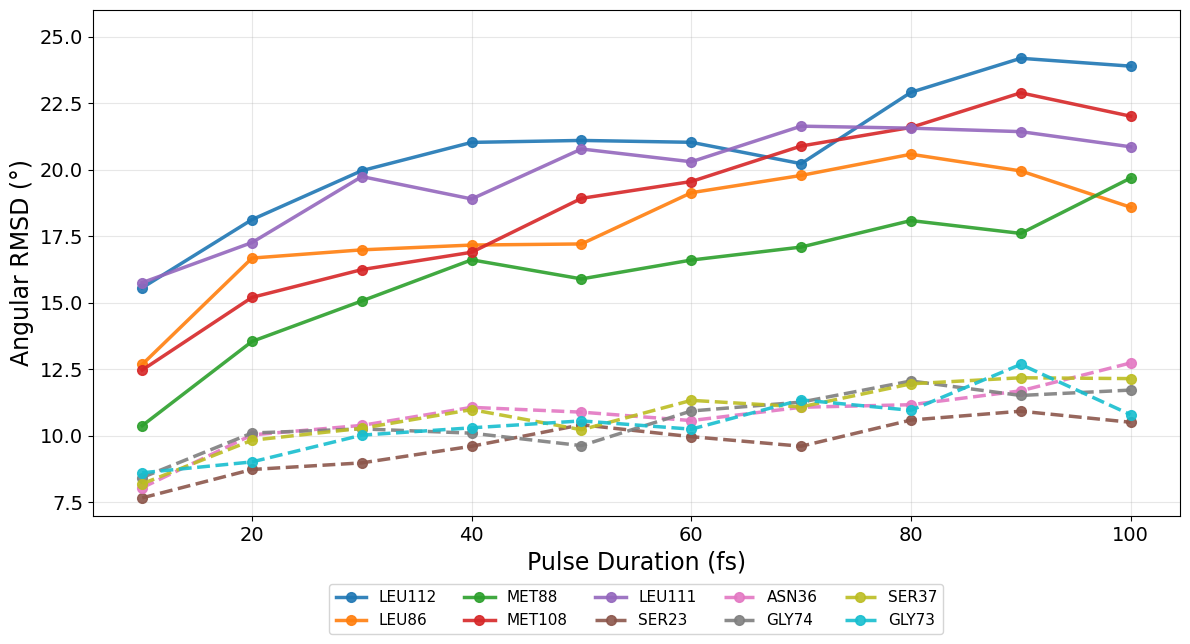

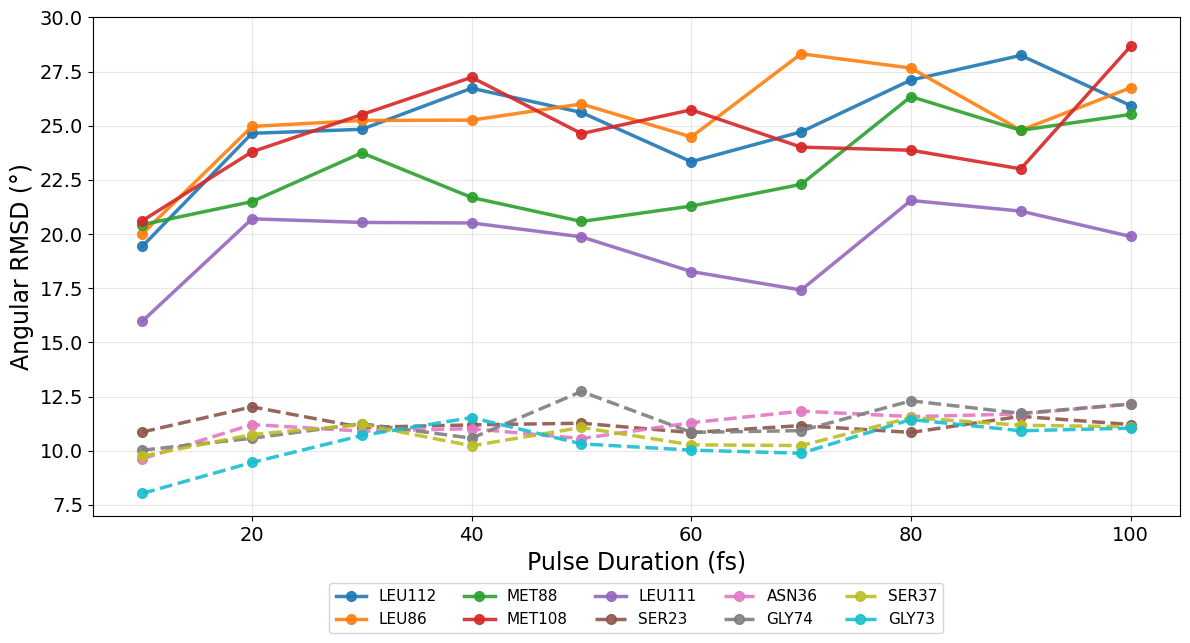

In [ ]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import MDAnalysis as mda

#paths
homogeneous_folder = (
    "/home/wilma/harryshouse/output_data/"
    "duration_sweep_2MS2"
)

heterogeneous_folder = (
    "/home/wilma/harryshouse/output_data/"
    "diff_structures_duration"
)

SELECT_HEAVY = True

#resiudes of interest (want to look at the same residues as for intensity simulations)
most_variable = [
    "LEU112",
    "LEU86",
    "MET88",
    "MET108",
    "LEU111"
]

least_variable = [
    "SER23",
    "ASN36",
    "GLY74",
    "SER37",
    "GLY73"
]

interesting_residues = (
    most_variable +
    least_variable
)

#colors for plotting
residue_colors = {

    # Most variable
    "LEU112": "#1f77b4",
    "LEU86":  "#ff7f0e",
    "MET88":  "#2ca02c",
    "MET108": "#d62728",
    "LEU111": "#9467bd",

    # Least variable
    "SER23":  "#8c564b",
    "ASN36":  "#e377c2",
    "GLY74":  "#7f7f7f",
    "SER37":  "#bcbd22",
    "GLY73":  "#17becf"
}


#load data
def load_from_h5(rep_path):

    h5_file = os.path.join(
        rep_path,
        "results.h5"
    )

    # Handle both gro filenames
    if os.path.exists(
        os.path.join(rep_path, "conf.gro")
    ):

        gro_file = os.path.join(
            rep_path,
            "conf.gro"
        )

    elif os.path.exists(
        os.path.join(rep_path, "equilibrated.gro")
    ):

        gro_file = os.path.join(
            rep_path,
            "equilibrated.gro"
        )

    else:

        return None

    if not os.path.exists(h5_file):

        return None

    try:

        with h5py.File(h5_file, 'r') as f:

            velf = f["final_velocity"][:]

        # Heavy atoms only
        if SELECT_HEAVY:

            u = mda.Universe(gro_file)

            heavy_idx = u.select_atoms(
                "not name H*"
            ).indices

            velf = velf[heavy_idx]

        return velf

    except Exception as e:

        print(f"[warn] {rep_path}: {e}")

        return None


#residue angular rmsd
def compute_angular_variability_per_residue(
    sim_output,
    duration_name
):

    dur_path = os.path.join(
        sim_output,
        duration_name
    )

    all_vels = []

    residue_info = None

    for rep in sorted(os.listdir(dur_path)):

        rep_path = os.path.join(
            dur_path,
            rep
        )

        if not os.path.isdir(rep_path):

            continue

        v = load_from_h5(rep_path)

        if v is None:

            continue

        try:

            h5_file = os.path.join(
                rep_path,
                "results.h5"
            )

            with h5py.File(h5_file, 'r') as f:

                atom_names = f["atom_names"][:]

                residue_ids = f["residue_ids"][:]

                residue_names = f["residue_names"][:]

                elements = np.array([
                    (
                        n.decode('utf-8')
                        if isinstance(n, bytes)
                        else n
                    ).strip()[0].upper()
                    for n in atom_names
                ])

                heavy_mask = elements != 'H'

                # Store residue info once
                if residue_info is None:

                    residue_info = {

                        'resids':
                            residue_ids[heavy_mask],

                        'resnames':
                            np.array([
                                n.decode('utf-8')
                                if isinstance(n, bytes)
                                else n
                                for n in residue_names[heavy_mask]
                            ])
                    }

            all_vels.append(v)

        except Exception as e:

            print(f"Error {rep}: {e}")

            continue

    # Need at least 2 replicas
    if len(all_vels) < 2:

        print(
            f"[skip] {duration_name}: "
            f"only {len(all_vels)} replica(s)"
        )

        return None

    #angular rmsd
    V = np.array(all_vels)

    # Normalize vectors
    norms = np.linalg.norm(
        V,
        axis=2,
        keepdims=True
    )

    norms[norms == 0] = 1.0

    V_unit = V / norms

    # Mean direction
    mean_V = np.mean(
        V_unit,
        axis=0
    )

    mean_norms = np.linalg.norm(
        mean_V,
        axis=1
    )

    valid = mean_norms > 1e-8

    mean_unit = np.zeros_like(mean_V)

    mean_unit[valid] = (
        mean_V[valid] /
        mean_norms[valid, None]
    )

    # Compute angles
    cos_theta = np.sum(
        V_unit * mean_unit[None, :, :],
        axis=2
    )

    cos_theta = np.clip(
        cos_theta,
        -1.0,
        1.0
    )

    angles = np.degrees(
        np.arccos(cos_theta)
    )

    angular_rmsd_per_atom = np.std(
        angles,
        axis=0
    )

   #group by residue
    unique_resids = np.unique(
        residue_info['resids']
    )

    residue_data = {}

    for resid in unique_resids:

        res_mask = (
            (residue_info['resids'] == resid)
            & valid
        )

        if np.sum(res_mask) == 0:

            continue

        resname_idx = np.where(
            residue_info['resids'] == resid
        )[0][0]

        resname = (
            residue_info['resnames'][resname_idx]
        )

        residue_label = f"{resname}{resid}"

        residue_data[residue_label] = {

            'rmsd': np.mean(
                angular_rmsd_per_atom[res_mask]
            ),

            'n_atoms': np.sum(res_mask)
        }

    return residue_data


#plotting
def plot_residue_dataset(
    simulation_folder,
    dataset_name
):

    duration_dirs = sorted(
        [d for d in os.listdir(simulation_folder)
         if d.startswith("dur_")],

        key=lambda d: float(
            d.split("_")[1].replace("fs", "")
        )
    )

    residue_vs_duration = {
        r: [] for r in interesting_residues
    }

    duration_values = []

    for ddir in duration_dirs:

        duration = float(
            ddir.replace("dur_", "")
                .replace("fs", "")
        )

        res_data = (
            compute_angular_variability_per_residue(
                simulation_folder,
                ddir
            )
        )

        if res_data is None:

            continue

        duration_values.append(duration)

        for residue in interesting_residues:

            if residue in res_data:

                residue_vs_duration[
                    residue
                ].append(
                    res_data[residue]['rmsd']
                )

            else:

                residue_vs_duration[
                    residue
                ].append(np.nan)

    
    plt.figure(figsize=(12, 7))

    for residue in interesting_residues:

        rmsds = residue_vs_duration[residue]

        if all(np.isnan(rmsds)):

            continue

        is_least_variable = (
            residue in least_variable
        )

        linestyle = (
            '--' if is_least_variable else '-'
        )

        plt.plot(
            duration_values,
            rmsds,
            marker='o',
            linestyle=linestyle,
            linewidth=2.5,
            markersize=7,
            label=residue,
            alpha=0.9,
            color=residue_colors[residue]
        )

    
    plt.xlabel(
        'Pulse Duration (fs)',
        fontsize=17
    )

    plt.ylabel(
        'Angular RMSD (°)',
        fontsize=17
    )

    #fix the axes values
    if dataset_name == "Homogeneous":

        plt.ylim(7, 26)

        plt.yticks(
            np.arange(7.5, 27, 2.5),
            fontsize=14
        )

    else:

        plt.ylim(7, 30)

        plt.yticks(
            np.arange(7.5, 31, 2.5),
            fontsize=14
        )

    
    plt.grid(
        True,
        alpha=0.3
    )
    plt.tick_params(labelsize=14)
    # Legend
    plt.legend(
        fontsize=11,
        ncol=5,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),

        frameon=True,
        fancybox=True,
        framealpha=0.95,

        edgecolor='lightgray',

        columnspacing=1.8,
        handlelength=2
    )

    plt.tight_layout()

    plt.show()


#plots for both datasets
plot_residue_dataset(
    homogeneous_folder,
    "Homogeneous"
)

plot_residue_dataset(
    heterogeneous_folder,
    "Heterogeneous"
)